<a href="https://colab.research.google.com/github/ashishsantikari/project-nlp-challenge/blob/main/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Plan of action



1.   EDA
2.   Feature Engineering
3.   Convert to embeddings
4.   Random Forest  | LR | NB | SVM



1 embedding, 2 models , 2+ embedding





# Links to the files

In [ ]:
data_url = "https://raw.githubusercontent.com/ironhack-labs/project-nlp-challenge/refs/heads/main/dataset/data.csv"

real_data_url = "https://raw.githubusercontent.com/ironhack-labs/project-nlp-challenge/refs/heads/main/dataset/validation_data.csv"

In [ ]:
# Install the required packages
!pip install numpy pandas scikit-learn matplotlib seaborn tabulate

# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd

data = pd.read_csv(data_url)

# look at the data format
display(data.head(10))

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,1,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,1,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,1,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,1,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,1,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


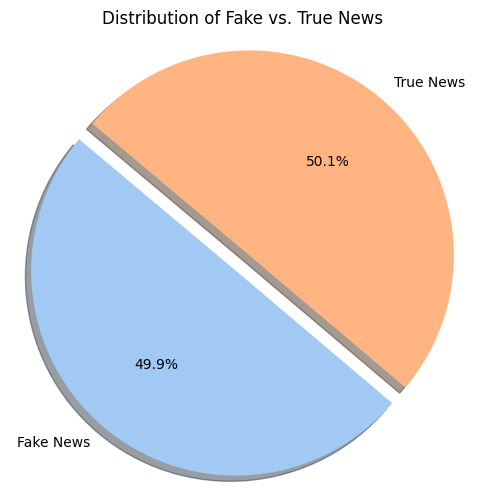

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fake_news_count = data['label'].value_counts()[0]
true_news_count = data['label'].value_counts()[1]

# Data for the pie chart
labels = ['Fake News', 'True News']
sizes = [fake_news_count, true_news_count]
# Use seaborn pastel palette
colors = sns.color_palette('pastel')[0:2]
explode = (0.1, 0)

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')
plt.title('Distribution of Fake vs. True News')
plt.show()

As the count of fake news and true news has not so much variation, we are not going with sampling of data.

## Title and Text Length Comparision

As fake news can be using very bloated text or very short attention seeking text, a general idea of the length of text could give us a lot of idea on classification.

In [ ]:
data['title_length'] = data['title'].apply(len)
data['text_length'] = data['text'].apply(len)

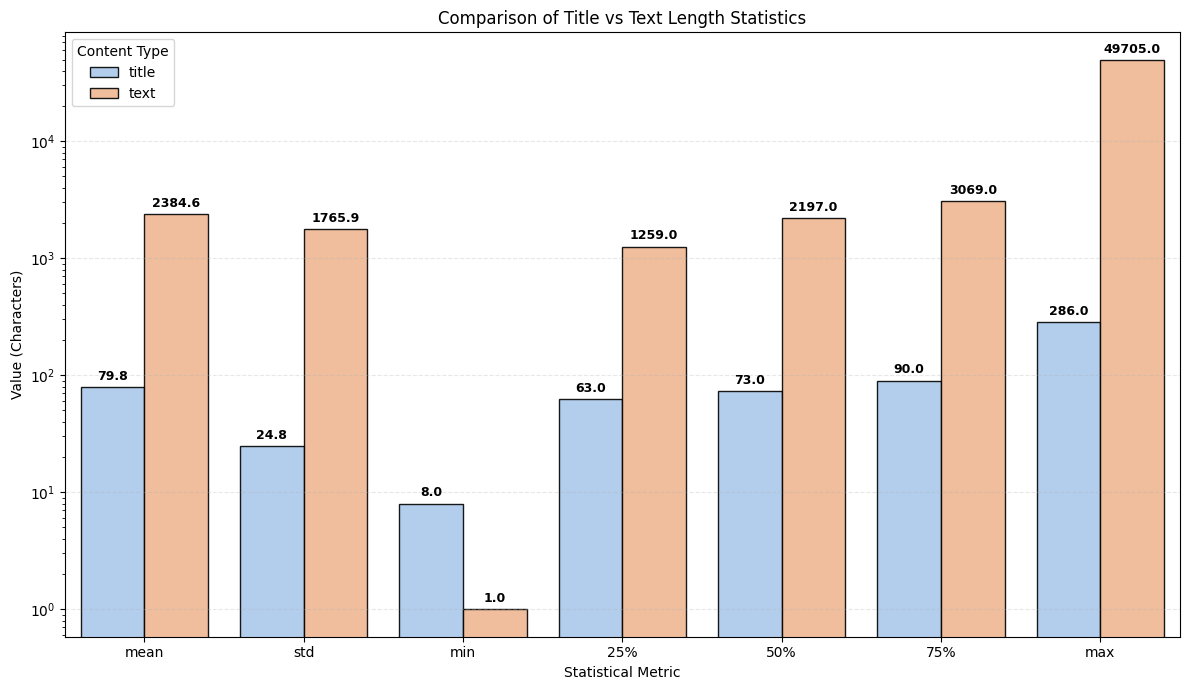

In [ ]:
# Use basic statistics and visualize with Seaborn using pastel palette and bar labels
from tabulate import tabulate
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = {}
results['title'] = data['title_length'].describe()
results['text'] = data['text_length'].describe()

df = pd.DataFrame(results)

# Prepare data for Seaborn plotting
df_plot = df.drop('count').reset_index().melt(id_vars='index', var_name='Type', value_name='Length')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_plot, x='index', y='Length', hue='Type', palette='pastel', edgecolor='black', alpha=0.9)

# Adding values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontweight='bold', fontsize=9)

plt.title('Comparison of Title vs Text Length Statistics')
plt.xlabel('Statistical Metric')
plt.ylabel('Value (Characters)')
plt.yscale('log') # Using log scale because text length is significantly larger than title
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

## Text length comparision


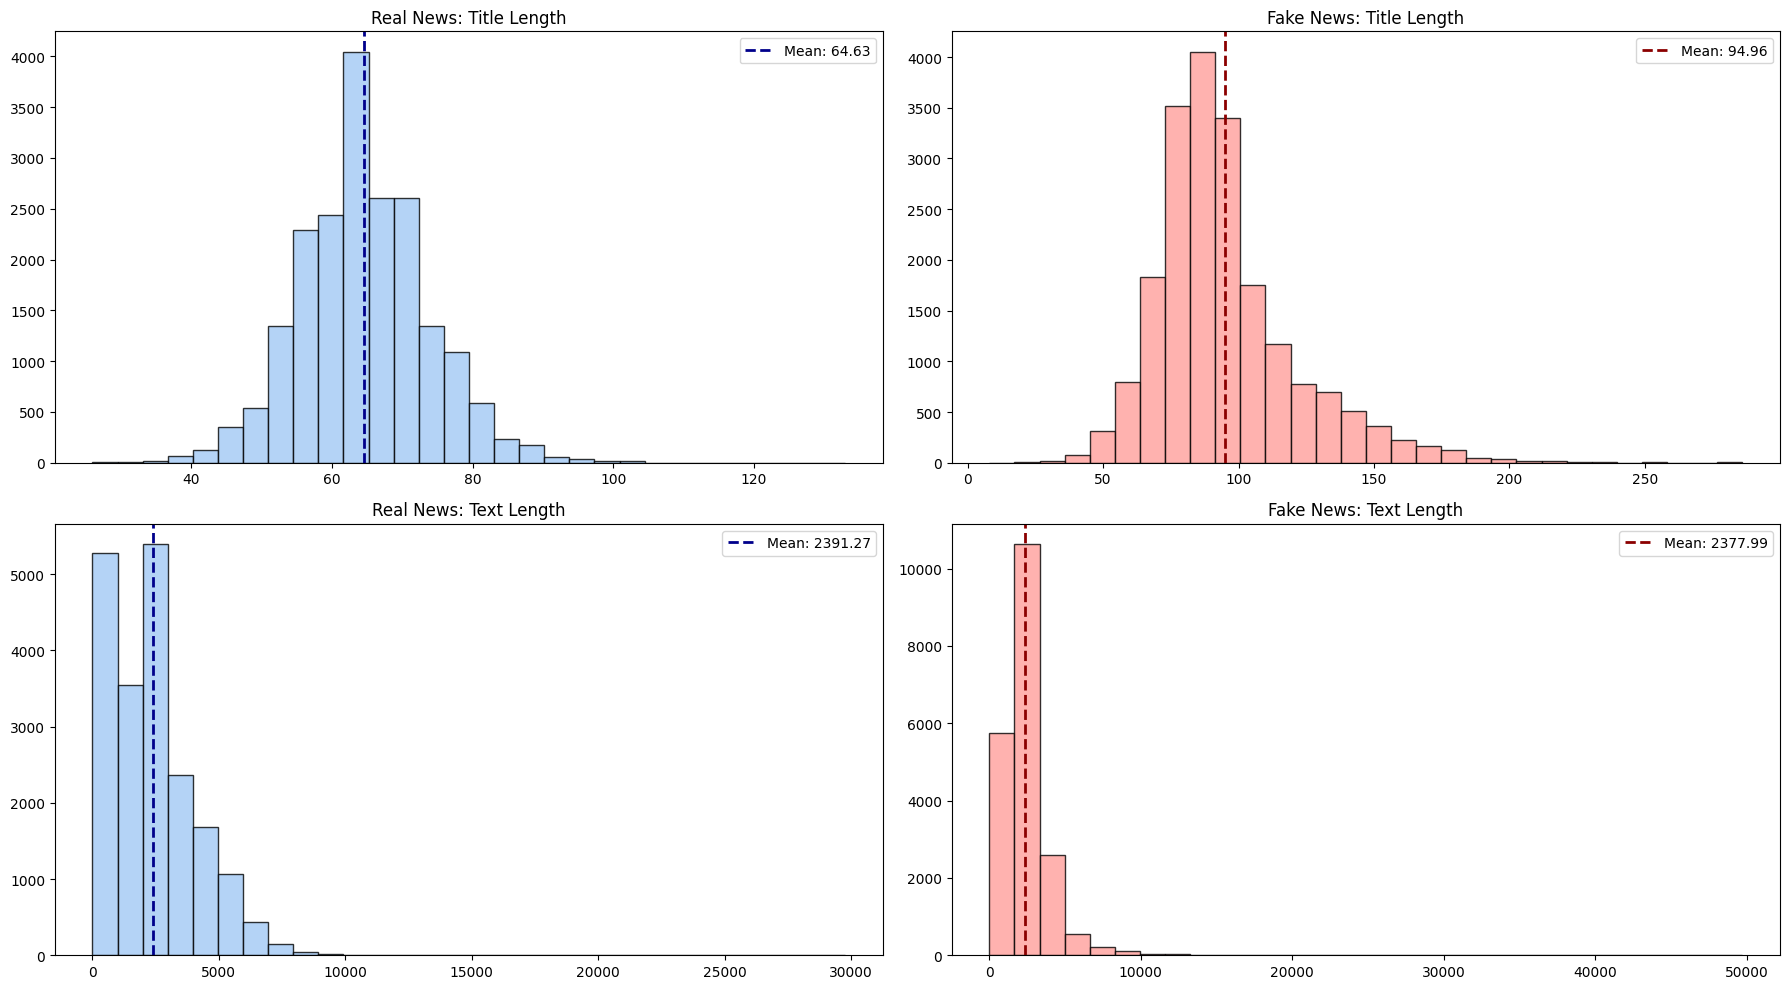

In [ ]:
# Ensure columns exist and create histograms comparing Real vs Fake news lengths
import matplotlib.pyplot as plt
import seaborn as sns

# Re-calculate lengths to be absolutely sure they exist in 'data'
data['title_length'] = data['title'].apply(len)
data['text_length'] = data['text'].apply(len)

# Get pastel colors
pastel_colors = sns.color_palette('pastel')
blue_pastel = pastel_colors[0]
red_pastel = pastel_colors[3]

# Refresh subsets
data_real = data[data['label'] == 1]
data_fake = data[data['label'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Real News - Title Length
title_mean_real = data_real['title_length'].mean()
axes[0, 0].hist(data_real['title_length'], bins=30, color=blue_pastel, alpha=0.8, edgecolor='black')
axes[0, 0].axvline(title_mean_real, color='darkblue', linestyle='dashed', linewidth=2, label=f'Mean: {title_mean_real:.2f}')
axes[0, 0].set_title('Real News: Title Length')
axes[0, 0].legend()

# Fake News - Title Length
title_mean_fake = data_fake['title_length'].mean()
axes[0, 1].hist(data_fake['title_length'], bins=30, color=red_pastel, alpha=0.8, edgecolor='black')
axes[0, 1].axvline(title_mean_fake, color='darkred', linestyle='dashed', linewidth=2, label=f'Mean: {title_mean_fake:.2f}')
axes[0, 1].set_title('Fake News: Title Length')
axes[0, 1].legend()

# Real News - Text Length
text_mean_real = data_real['text_length'].mean()
axes[1, 0].hist(data_real['text_length'], bins=30, color=blue_pastel, alpha=0.8, edgecolor='black')
axes[1, 0].axvline(text_mean_real, color='darkblue', linestyle='dashed', linewidth=2, label=f'Mean: {text_mean_real:.2f}')
axes[1, 0].set_title('Real News: Text Length')
axes[1, 0].legend()

# Fake News - Text Length
text_mean_fake = data_fake['text_length'].mean()
axes[1, 1].hist(data_fake['text_length'], bins=30, color=red_pastel, alpha=0.8, edgecolor='black')
axes[1, 1].axvline(text_mean_fake, color='darkred', linestyle='dashed', linewidth=2, label=f'Mean: {text_mean_fake:.2f}')
axes[1, 1].set_title('Fake News: Text Length')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Comparision of real vs fake

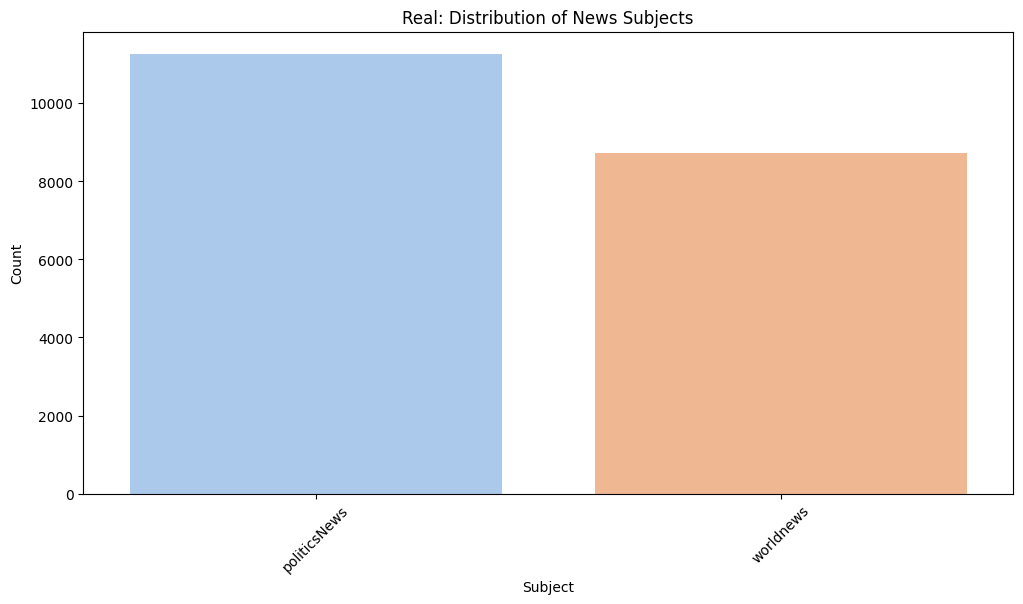

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate counts for each subject
r_subject_counts = data[data['label'] == 1]['subject'].value_counts().reset_index()
r_subject_counts.columns = ['subject', 'count']

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=r_subject_counts, x='subject', y='count', hue='subject', palette='pastel', legend=False)
plt.title('Real: Distribution of News Subjects')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

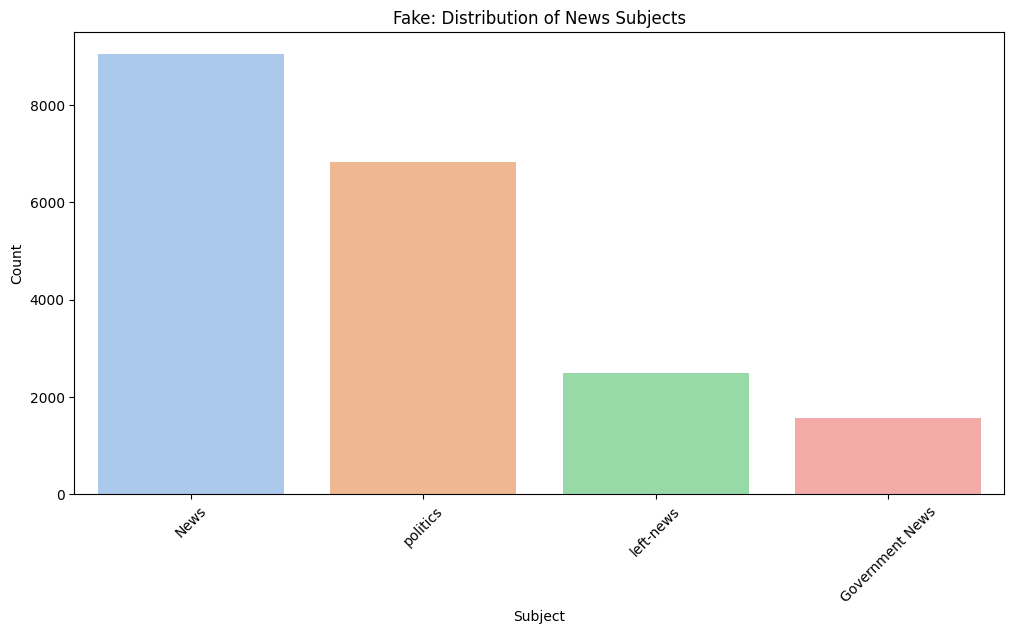

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate counts for each subject
f_subject_counts = data[data['label'] == 0]['subject'].value_counts().reset_index()
f_subject_counts.columns = ['subject', 'count']

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=f_subject_counts, x='subject', y='count', hue='subject', palette='pastel', legend=False)
plt.title('Fake: Distribution of News Subjects')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Data Cleanup

In [ ]:
# Data Cleanup
import re

def clean_links(text):
  # clean https and links from text
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'www\S+', '', text)
  return text

def clean_punctuations(text):
  text = re.sub(r'[^\w\s]', '', text)
  return text

def data_cleanup(text):
  text = text.lower()
  text = clean_links(text)
  text = clean_punctuations(text)
  return text


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from scipy.sparse import hstack
import numpy as np
from sklearn.model_selection import train_test_split


y = data['label']
data['text'] = data['text'].apply(data_cleanup)
data['title'] = data['title'].apply(data_cleanup)

X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, random_state=42, stratify=y)

# 1. Process Text using CountVectorizer and TfidfTransformer
cnt_vec_text = CountVectorizer(stop_words="english")
tfidf_trans_text = TfidfTransformer()
X_train_counts_text = cnt_vec_text.fit_transform(X_train["text"])
X_text = tfidf_trans_text.fit_transform(X_train_counts_text)

# 2. Process Title using CountVectorizer and TfidfTransformer
cnt_vec_title = CountVectorizer(stop_words="english")
tfidf_trans_title = TfidfTransformer()
X_train_counts_title = cnt_vec_title.fit_transform(X_train["title"])
X_title = tfidf_trans_title.fit_transform(X_train_counts_title)

# 3. Combine all features
X_combined_train = hstack([X_text, X_title])

print(f"Combined Training Feature Matrix Shape: {X_combined_train.shape}")

Combined Training Feature Matrix Shape: (31953, 205521)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, r2_score
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_metrics(title, y_test, y_pred):
  # Calculate Classification Metrics
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  # Calculate Error Metrics
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  # Prepare data for plotting
  metrics_names = ['Precision', 'Recall', 'F1-Score', 'MSE', 'RMSE', 'R2_SCORE']
  metrics_values = [precision, recall, f1, mse, rmse, r2]

  # display(classification_report(y_test, y_pred, target_names=['Fake News', 'Real News']))

  # Plotting using pastel palette
  plt.figure(figsize=(5, 3))
  sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='pastel', legend=False, edgecolor='black', alpha=0.8)

  # Adding values on top of the bars
  for i, val in enumerate(metrics_values):
      plt.text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

  plt.title(title)
  plt.ylabel('Score / Error Value')
  plt.ylim(0, 1.1)
  plt.grid(axis='y', linestyle='--', alpha=0.3)
  plt.show()



# Classifiers

## Naive Bayes Classification

In [ ]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack

# 1. Prepare Test Features using the fitted transformers
X_test_counts_text = cnt_vec_text.transform(X_test['text'].apply(data_cleanup))
X_test_text = tfidf_trans_text.transform(X_test_counts_text)

X_test_counts_title = cnt_vec_title.transform(X_test['title'].apply(data_cleanup))
X_test_title = tfidf_trans_title.transform(X_test_counts_title)

# 2. Combine Test Features (Matching X_combined_train which currently uses [X_text, X_title])
X_combined_test = hstack([X_test_text, X_test_title])

# 3. Initialize and Train Naive Bayes
nb_model = BernoulliNB(alpha=0.001)
nb_model.fit(X_combined_train, y_train)

# 4. Predict and Evaluate
y_pred_nb = nb_model.predict(X_combined_test)

#5. print summary
print("Naive Bayes Summary:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Summary:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3989
           1       0.99      0.98      0.98      4000

    accuracy                           0.98      7989
   macro avg       0.99      0.98      0.98      7989
weighted avg       0.99      0.98      0.98      7989



In [121]:
# Cross Validation with SVM
from sklearn.model_selection import cross_val_score

scores = cross_val_score(nb_model, X_combined_train, y_train, cv=5)
print(f"NB Cross-Validation Scores: {scores}")
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))

NB Cross-Validation Scores: [0.98231889 0.98325771 0.98310124 0.98200313 0.98184664]
0.98 accuracy with a standard deviation of 0.00


### Result of Naive Bayes

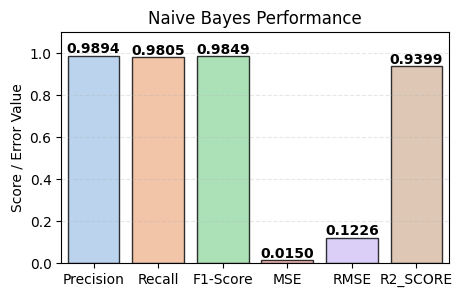

In [ ]:
plot_metrics("Naive Bayes Performance", y_test, y_pred_nb)

## Linear Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and Train Logistic Regression
# Increasing max_iter to ensure convergence on high-dimensional sparse data
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    solver='liblinear',
    fit_intercept=True
  )
lr_model.fit(X_combined_train, y_train)

# Predict and Evaluate
y_pred_lr = lr_model.predict(X_combined_test)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_nb))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3989
           1       0.99      0.98      0.98      4000

    accuracy                           0.98      7989
   macro avg       0.99      0.98      0.98      7989
weighted avg       0.99      0.98      0.98      7989



In [120]:
# Cross Validation with LR
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_model, X_combined_train, y_train, cv=5)
print(f"Linear Regression Cross-Validation Scores: {scores}")
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))

Linear Regression Cross-Validation Scores: [0.99280238 0.9906118  0.99327179 0.9915493  0.99264476]
0.99 accuracy with a standard deviation of 0.00


### Result of Linear Regression

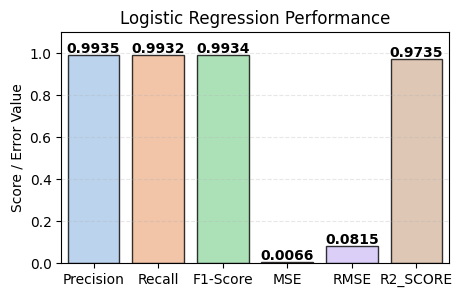

In [ ]:
plot_metrics("Logistic Regression Performance", y_test, y_pred_lr)

## Support Vector Machine Model

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize and Train SVM (LinearSVC)
# C=1.0 is the default regularization parameter
svm_model = LinearSVC(
    random_state=42,
    max_iter=2000,
    penalty='l1',
    dual=False
)
svm_model.fit(X_combined_train, y_train)

# Predict and Evaluate
y_pred_svm = svm_model.predict(X_combined_test)

print("SVM (LinearSVC) Performance:")
print(classification_report(y_test, y_pred_nb))

SVM (LinearSVC) Performance:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3989
           1       0.99      0.98      0.98      4000

    accuracy                           0.98      7989
   macro avg       0.99      0.98      0.98      7989
weighted avg       0.99      0.98      0.98      7989



### Result of Linear Support Vector Machines

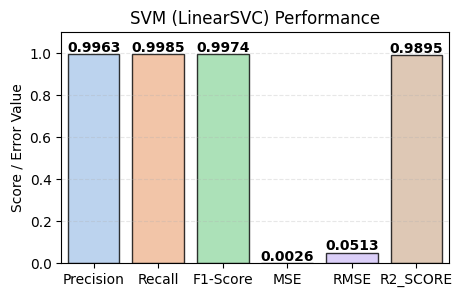

In [ ]:
plot_metrics("SVM (LinearSVC) Performance", y_test, y_pred_svm)

In [119]:
# Cross Validation with SVM
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm_model, X_combined_train, y_train, cv=5)
print(f"Support Vector Machines Cross-Validation Scores: {scores}")
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))


Support Vector Machines Cross-Validation Scores: [0.99765295 0.99734001 0.99734001 0.99593114 0.99733959]
1.00 accuracy with a standard deviation of 0.00


# Aggregate Report

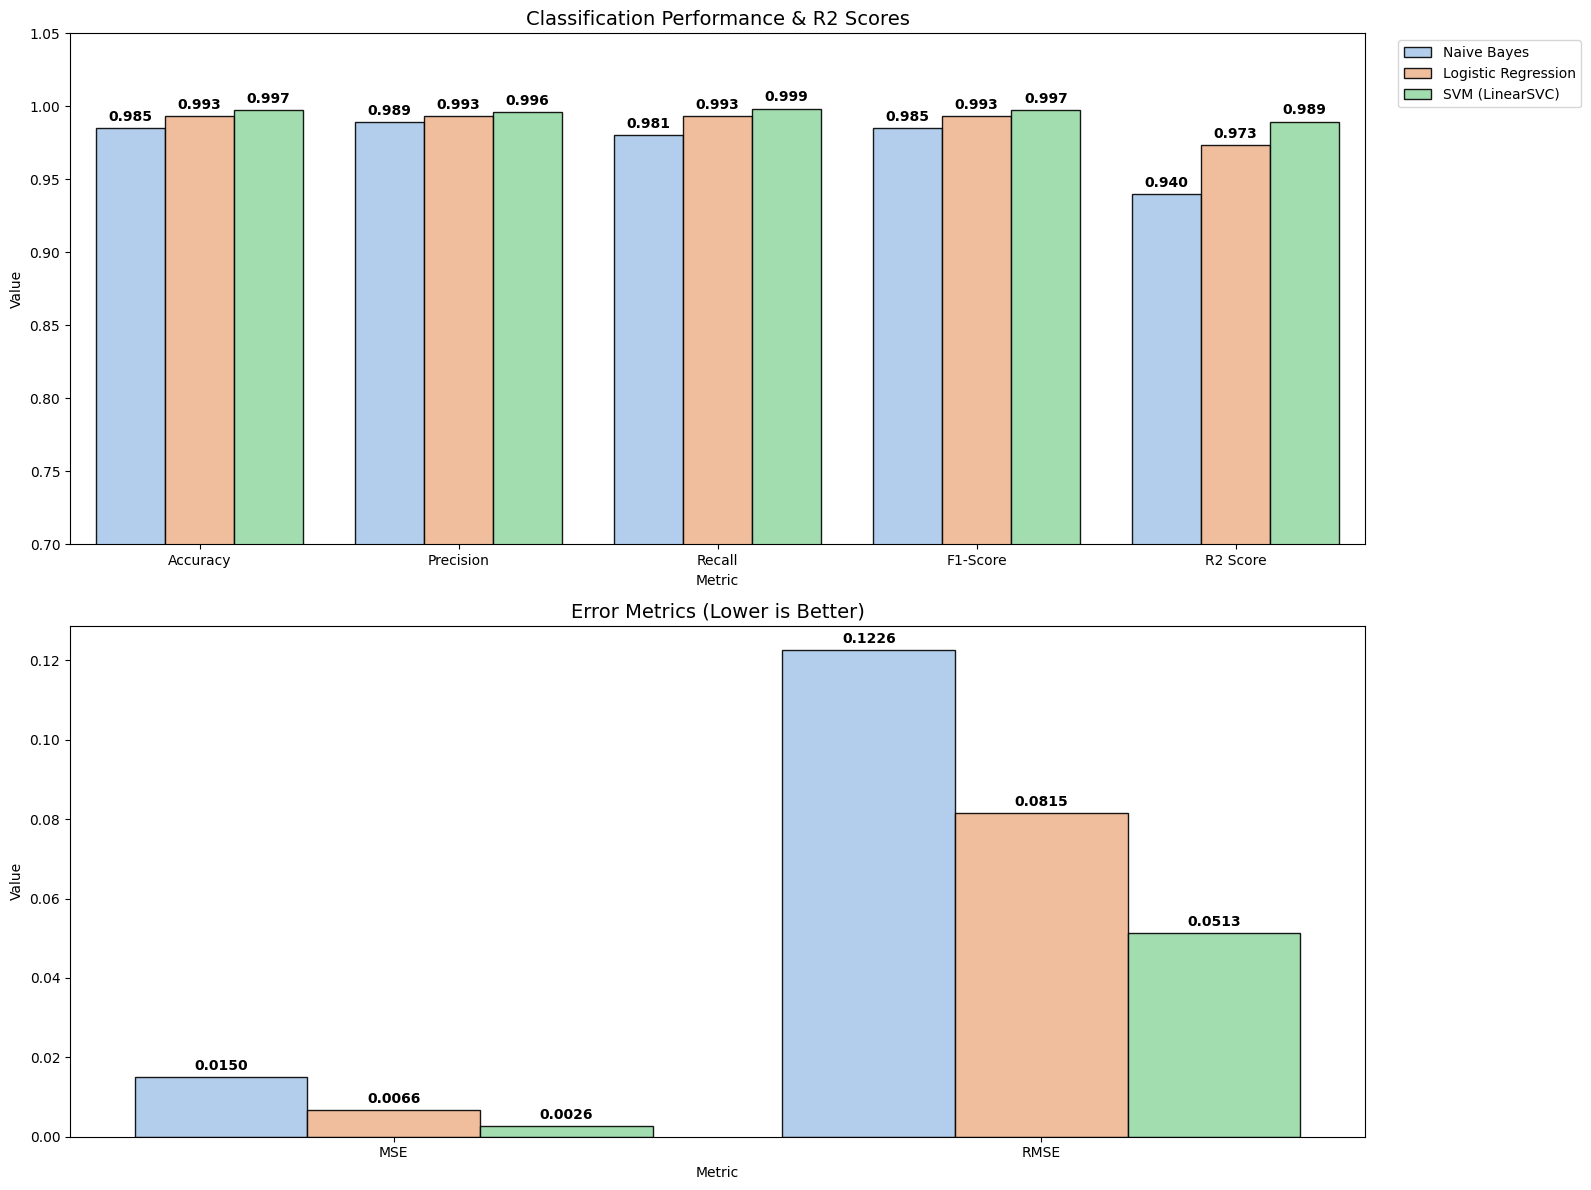

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, mean_squared_error, r2_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define the models and their predictions
model_results = [
    ('Naive Bayes', y_pred_nb),
    ('Logistic Regression', y_pred_lr),
    ('SVM (LinearSVC)', y_pred_svm)
]

# Gather metrics for each model
metrics_data = []
for name, pred in model_results:
    mse_val = mean_squared_error(y_test, pred)
    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'MSE': mse_val,
        'RMSE': np.sqrt(mse_val),
        'R2 Score': r2_score(y_test, pred)
    })

# Convert to DataFrame
df_all = pd.DataFrame(metrics_data)

# Move R2 Score to the error metrics plot or keep it in scores with a wider scale
# Let's keep R2 Score in ax1 but expand the Y-axis limit
score_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'R2 Score']
error_metrics = ['MSE', 'RMSE']

df_scores = df_all.melt(id_vars='Model', value_vars=score_metrics, var_name='Metric', value_name='Value')
df_errors = df_all.melt(id_vars='Model', value_vars=error_metrics, var_name='Metric', value_name='Value')

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Plot Scores - Adjusted Y-limit to catch lower R2 scores
sns.barplot(data=df_scores, x='Metric', y='Value', hue='Model', palette='pastel', ax=ax1, edgecolor='black', alpha=0.9)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', padding=3, fontweight='bold')
ax1.set_title('Classification Performance & R2 Scores', fontsize=14)
ax1.set_ylim(0.7, 1.05) # Lowered limit to make R2 visible for all models
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Plot Errors
sns.barplot(data=df_errors, x='Metric', y='Value', hue='Model', palette='pastel', ax=ax2, edgecolor='black', alpha=0.9)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', padding=3, fontweight='bold')
ax2.set_title('Error Metrics (Lower is Better)', fontsize=14)
ax2.legend().set_visible(False)

plt.tight_layout()
plt.show()

# Test with Real Data


In [ ]:
real_data = pd.read_csv(real_data_url)

# cleanup
real_data['text'] = real_data['text'].apply(data_cleanup)
real_data['title'] = real_data['title'].apply(data_cleanup)

# embedding - MUST use the original transformers fitted on training data
# 1. Process Real Text
X_real_counts_text = cnt_vec_text.transform(real_data["text"])
X_real_text = tfidf_trans_text.transform(X_real_counts_text)

# 2. Process Real Title
X_real_counts_title = cnt_vec_title.transform(real_data["title"])
X_real_title = tfidf_trans_title.transform(X_real_counts_title)

# 3. Combine features (Matching the training format [X_text, X_title])
X_combined_real = hstack([X_real_text, X_real_title])

# Predict using the trained models
result_nb_real = nb_model.predict(X_combined_real)
result_lr_real = lr_model.predict(X_combined_real)
result_svm_real = svm_model.predict(X_combined_real)

# Display some results
real_data['NB_Prediction'] = result_nb_real
real_data['LR_Prediction'] = result_lr_real
real_data['SVM_Prediction'] = result_svm_real

result = real_data.copy()
result['label'] = svm_model.predict(X_combined_real)


# display(real_data[['title', 'NB_Prediction', 'LR_Prediction', 'SVM_Prediction']].head(10))

In [ ]:
# Export the results to a CSV file
output_filename = 'real_data_predictions.csv'
result.to_csv(output_filename, index=False)

print(f"Results successfully exported to {output_filename}")

Results successfully exported to real_data_predictions.csv
